## Data Analysis on Used_Cars Dataset
by Ayan Suvra Bosu

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Part A: Data Loading and Initial Inspection

In [2]:
df = pd.read_csv('./Datasets/used_cars_data.csv')

In [3]:
df.head() # first five rows

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [4]:
df.tail() # last five rows

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.0,NaN,NaN


In [5]:
df.sample(5) # random 5 rows

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
1766,1766,Mercedes-Benz New C-Class C 200 Kompressor Ele...,Pune,2007,220000,Petrol,Automatic,Second,11.74 kmpl,1796 CC,186 bhp,5.0,NaN,6.0
3829,3829,Mahindra XUV500 W8 2WD,Ahmedabad,2014,31000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0,NaN,9.5
2615,2615,Renault Scala RxL,Kolkata,2013,45000,Petrol,Manual,First,16.95 kmpl,1498 CC,97.6 bhp,5.0,NaN,2.4
7037,7037,Ford Ecosport 1.5 DV5 MT Ambiente,Kochi,2017,61041,Diesel,Manual,First,22.7 kmpl,1498 CC,89.84 bhp,5.0,NaN,NaN
7221,7221,Honda City i-VTEC VX,Coimbatore,2018,31542,Petrol,Manual,First,17.4 kmpl,1497 CC,117.3 bhp,5.0,12.68 Lakh,NaN


In [6]:
df.shape

(7253, 14)

In [7]:
# columns name
df.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='str')

In [8]:
# making S.No. default index
df.set_index('S.No.', inplace=True)

In [9]:
# short description of all columns
df.describe(include='all')

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
count,7253,7253,7253.000000,7.253000e+03,7253,7253,7253,7251,7207,7207,7200.000000,1006,6019.000000
unique,2041,11,NaN,NaN,5,2,4,450,150,386,NaN,625,NaN
top,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,17.0 kmpl,1197 CC,74 bhp,NaN,95.13 Lakh,NaN
freq,55,949,NaN,NaN,3852,5204,5952,207,732,280,NaN,6,NaN
mean,NaN,NaN,2013.365366,5.869906e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.279722,NaN,9.479468
std,NaN,NaN,3.254421,8.442772e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.811660,NaN,11.187917
min,NaN,NaN,1996.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.440000
25%,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,3.500000
50%,NaN,NaN,2014.000000,5.341600e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,5.640000
75%,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,9.950000


In [10]:
# Adding Brand Name to df
brand = df['Name'].str.split().apply(lambda x:x[0])
df.insert(0, 'Brand', brand)

### Part B: Missing Data and Outliers

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              7253 non-null   str    
 1   Name               7253 non-null   str    
 2   Location           7253 non-null   str    
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   str    
 6   Transmission       7253 non-null   str    
 7   Owner_Type         7253 non-null   str    
 8   Mileage            7251 non-null   str    
 9   Engine             7207 non-null   str    
 10  Power              7207 non-null   str    
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   str    
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 793.4 KB


In [12]:
# total null values on each column
df.isnull().sum()

Brand                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [13]:
# dropping New_Price col
df.drop(columns=['New_Price'], inplace=True)

In [14]:
# dropping rows with Null price
df.dropna(subset=['Price'], inplace=True)

In [15]:
# Mileage col
df['Mileage'] = df['Mileage'].replace(np.nan, '-1 kmpl')
df['Mileage'] = df['Mileage'].str.split().apply(lambda x : x[0])
df['Mileage'] = df['Mileage'].astype('float')

# filling missig values
df['Mileage'] = df['Mileage'].replace(-1, df['Mileage'].median())

In [16]:
# Engine col
df['Engine'] = df['Engine'].replace(np.nan, '-1 CC')
df['Engine'] = df['Engine'].str.split().apply(lambda x : x[0])
df['Engine'] = df['Engine'].astype('int')

# filling missig values
df['Engine'] = df['Engine'].replace(-1, df['Engine'].median())

In [17]:
# power col
df['Power'] = df['Power'].str.split().str[0]
df['Power'] = pd.to_numeric(df['Power'], errors='coerce')

# Fill missing values with mean
df['Power'] = df['Power'].fillna(df['Power'].mean())

In [18]:
# seats col
df['Seats'] = df['Seats'].fillna(df['Seats'].median())
df['Seats'] = df['Seats'].astype('int64')

In [19]:
df.columns

Index(['Brand', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='str')

In [20]:
# modifing col name
df.rename(columns={
    'Mileage' : 'Mileage_kmpl',
    'Engine' : 'Engine_CC',
    'Power' : 'Power_bhp',
    'Price' : 'Price_lakhs'
}, inplace=True)

In [21]:
df

,Brand,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_lakhs
S.No.,,,,,,,,,,,,,
0,Maruti,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75
1,Hyundai,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50
2,Honda,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50
3,Maruti,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00
4,Audi,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248,74.00,5,4.75
6015,Hyundai,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120,71.00,5,4.00
6016,Mahindra,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498,112.00,8,2.90


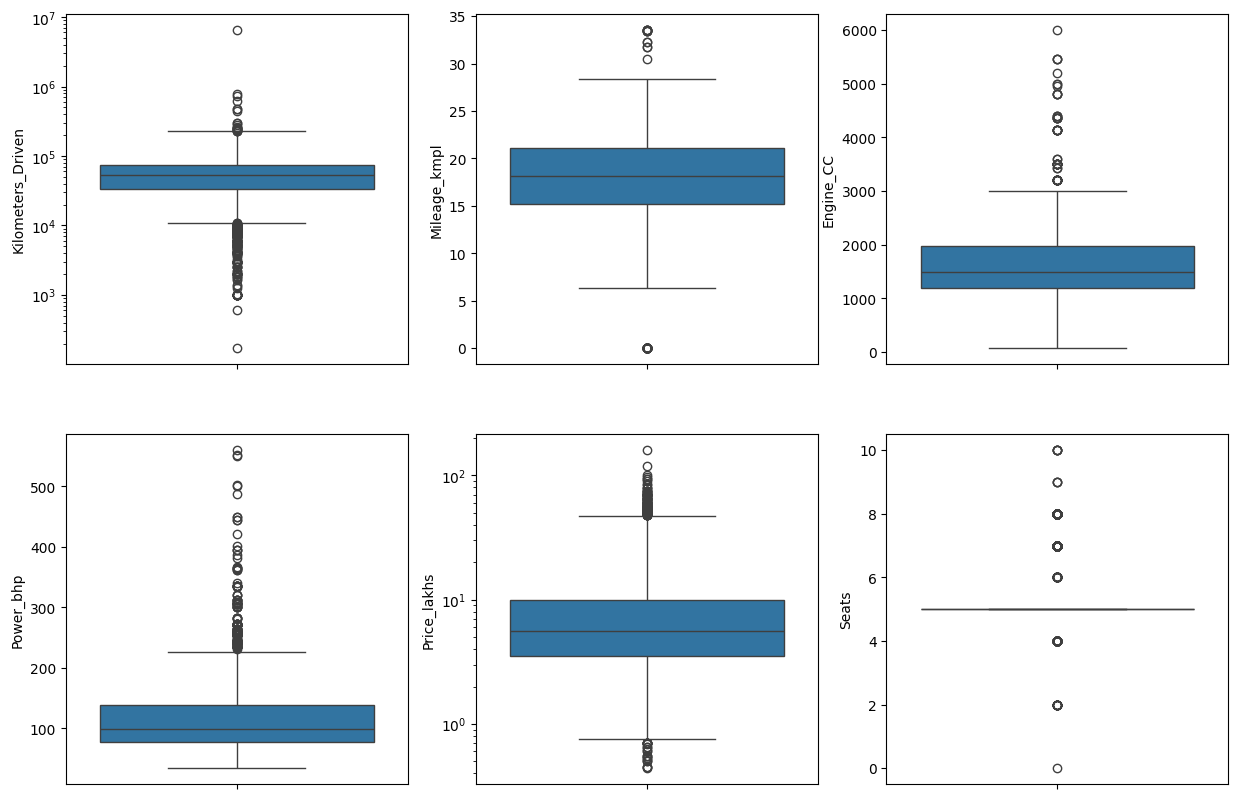

In [22]:
# detecting outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(df['Kilometers_Driven'],log_scale=True, ax=axes[0][0])
sns.boxplot(df['Mileage_kmpl'], ax=axes[0][1])
sns.boxplot(df['Engine_CC'], ax=axes[0][2])
sns.boxplot(df['Power_bhp'], ax=axes[1][0])
sns.boxplot(df['Price_lakhs'],log_scale=True, ax=axes[1][1])
sns.boxplot(df['Seats'], ax=axes[1][2])

plt.show()

### Part C: Distribution Analysis

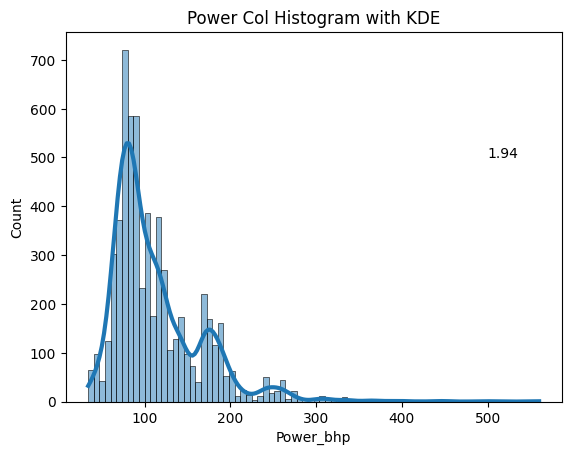

In [23]:
# histogram with KDE

# Power
sns.histplot(df['Power_bhp'], kde=True, line_kws={'linewidth':3})
plt.title('Power Col Histogram with KDE')
plt.text(500, 500, round(df['Power_bhp'].skew(), 3))
plt.show()

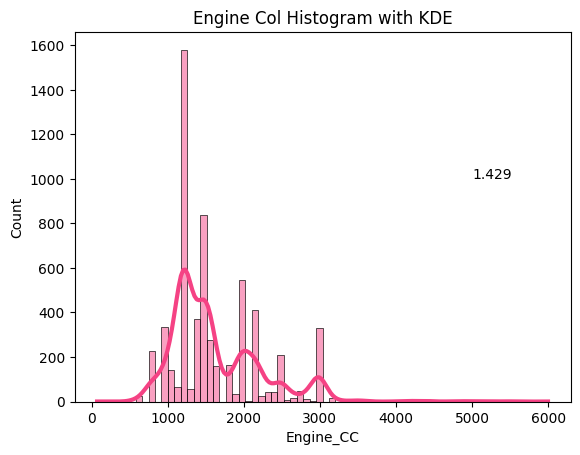

In [24]:
# Engine CC
sns.histplot(df['Engine_CC'], kde=True, line_kws={'linewidth':3}, color='#f54284')
plt.title('Engine Col Histogram with KDE')
plt.text(5000, 1000, round(df['Engine_CC'].skew(), 3))
plt.show()

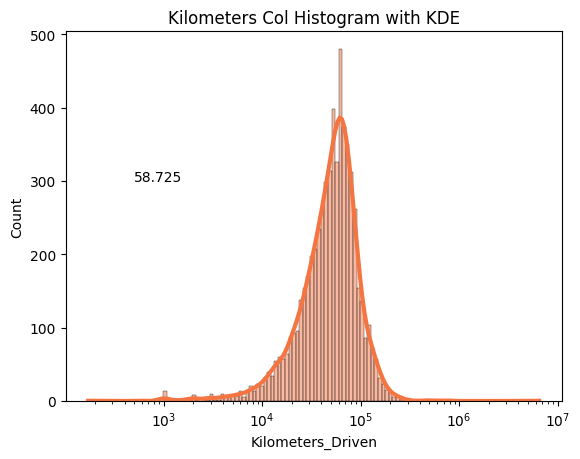

In [25]:
# Kilometers_driven
sns.histplot(df['Kilometers_Driven'], kde=True, line_kws={'linewidth':3}, log_scale=True, color='#f57542')
plt.title('Kilometers Col Histogram with KDE')
plt.text(500, 300, round(df['Kilometers_Driven'].skew(), 3))
plt.show()

### Part D: Correlation Analysis

In [26]:
corr_table = df[['Year', 'Kilometers_Driven', 'Mileage_kmpl', 'Engine_CC', 'Power_bhp', 'Price_lakhs']].corr()
corr_table

,Year,Kilometers_Driven,Mileage_kmpl,Engine_CC,Power_bhp,Price_lakhs
Year,1.000000,-0.173048,0.321534,-0.050086,0.013895,0.305327
Kilometers_Driven,-0.173048,1.000000,-0.065253,0.090890,0.033419,-0.011493
Mileage_kmpl,0.321534,-0.065253,1.000000,-0.586404,-0.506803,-0.306588
Engine_CC,-0.050086,0.090890,-0.586404,1.000000,0.858903,0.657347
Power_bhp,0.013895,0.033419,-0.506803,0.858903,1.000000,0.767331
Price_lakhs,0.305327,-0.011493,-0.306588,0.657347,0.767331,1.000000


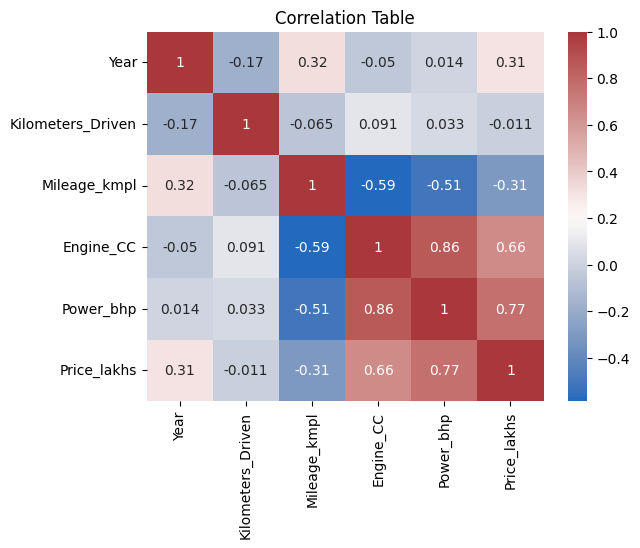

In [27]:
sns.heatmap(corr_table, annot=True, cmap='vlag')
plt.title('Correlation Table')

plt.show()

Correlation
- Power and Engine has high positive correlation
- Power and Price has a  positive correlation
- Engine and Price has a positive correlation
- Mileage has negetive correlation with Engine and Power

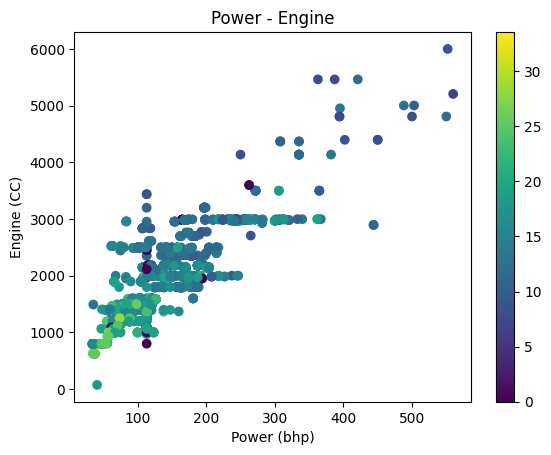

In [28]:
# Scatter Plot Power - Engine
plt.scatter(x=df['Power_bhp'], y=df['Engine_CC'], c=df['Mileage_kmpl'])

plt.title('Power - Engine')
plt.xlabel('Power (bhp)')
plt.ylabel('Engine (CC)')

plt.colorbar()
plt.show()

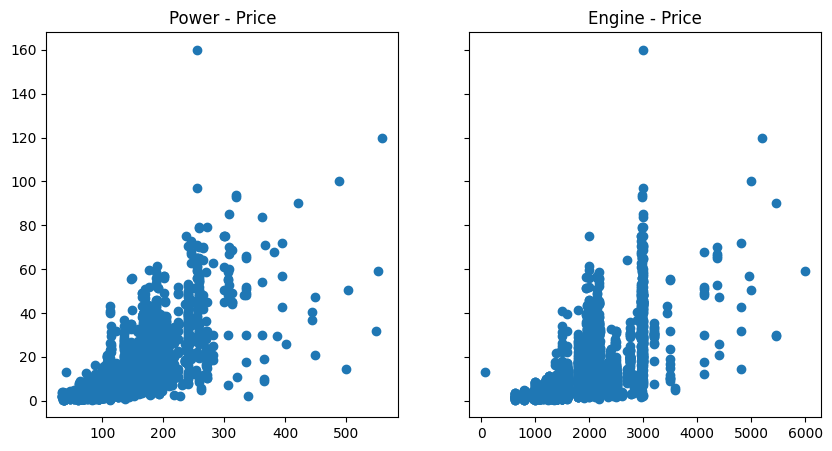

In [29]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

axes[0].scatter(x=df['Power_bhp'], y=df['Price_lakhs'])
axes[0].set_title('Power - Price')

axes[1].scatter(x=df['Engine_CC'], y=df['Price_lakhs'])
axes[1].set_title('Engine - Price')

plt.show()

### Part E: Group by Analysis

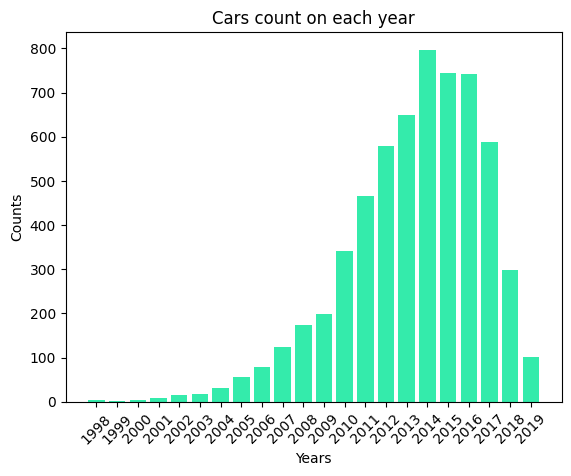

In [30]:
# number of cars, each year
cars_each_year = df.groupby(by='Year')['Name'].count()
plt.bar(x=cars_each_year.index, height=cars_each_year.values, color='#34ebab', )

plt.xlabel('Years')
plt.ylabel('Counts')

plt.xticks(cars_each_year.index, rotation=45)

plt.title('Cars count on each year')

plt.show()
# most cars sold on 2014

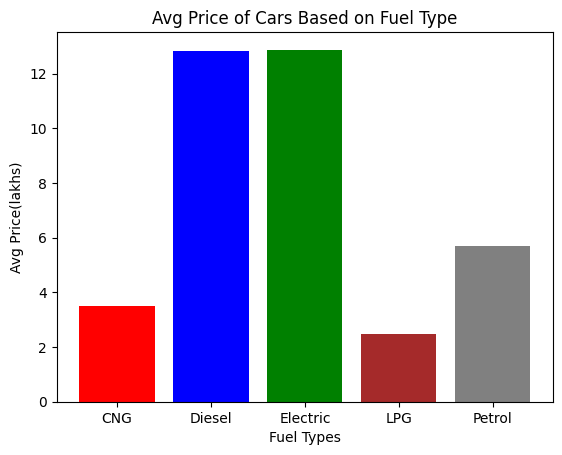

In [31]:
# avg price based on fule type
fuel_type_avg_price = df.groupby('Fuel_Type')['Price_lakhs'].mean()

plt.bar(x=fuel_type_avg_price.index, height=fuel_type_avg_price.values, color=['red', 'blue', 'green', 'brown', 'gray'])

plt.xlabel('Fuel Types')
plt.ylabel('Avg Price(lakhs)')

plt.title('Avg Price of Cars Based on Fuel Type')

plt.show()

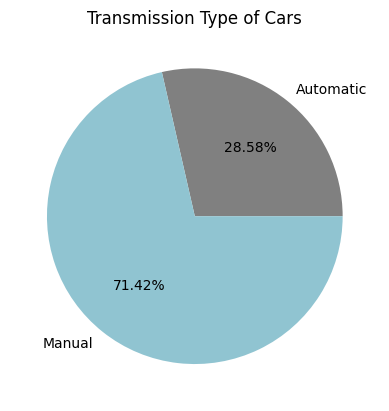

In [32]:
# Transmission
transmission_type = df.groupby('Transmission')['Transmission'].value_counts()

plt.pie(transmission_type, labels=transmission_type.index, autopct='%1.2f%%', colors=['gray', '#90c4d1'])

plt.title('Transmission Type of Cars')

plt.show()
# most of the cars are mannual

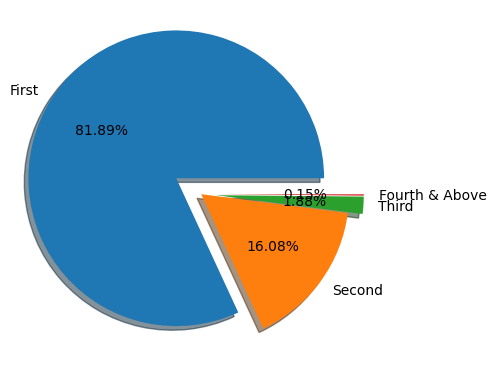

In [33]:
# owner type
owner_type = df['Owner_Type'].value_counts()

plt.pie(owner_type, autopct='%1.2f%%', labels=owner_type.index, explode=(0.2, 0, 0.1, 0.1), shadow=True)

plt.show()
# most people prefer new cars

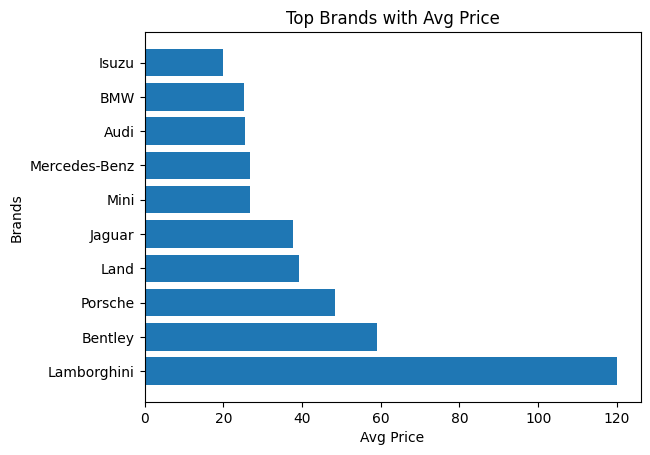

In [34]:
# Top 10 brands with high avg prices
brands_avg_price = df.groupby('Brand')['Price_lakhs'].mean().sort_values(ascending=False).head(10)

plt.barh(y=brands_avg_price.index, width=brands_avg_price.values)

plt.ylabel('Brands')
plt.xlabel('Avg Price')
plt.title('Top Brands with Avg Price')

plt.show()

### Part F: Statistical Inference

In [35]:
df.describe(include='all')

,Brand,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_lakhs
count,6019,6019,6019,6019.000000,6.019000e+03,6019,6019,6019,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
unique,31,1876,11,NaN,NaN,5,2,4,NaN,NaN,NaN,NaN,NaN
top,Maruti,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,NaN,NaN,NaN,NaN,NaN
freq,1211,49,790,NaN,NaN,3205,4299,4929,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2013.358199,5.873838e+04,NaN,NaN,NaN,18.134966,1620.509221,113.253050,5.276790,9.479468
std,NaN,NaN,NaN,3.269742,9.126884e+04,NaN,NaN,NaN,4.581528,599.635458,53.231019,0.806346,11.187917
min,NaN,NaN,NaN,1998.000000,1.710000e+02,NaN,NaN,NaN,0.000000,72.000000,34.200000,0.000000,0.440000
25%,NaN,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,15.170000,1198.000000,78.000000,5.000000,3.500000
50%,NaN,NaN,NaN,2014.000000,5.300000e+04,NaN,NaN,NaN,18.150000,1493.000000,98.600000,5.000000,5.640000
75%,NaN,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,21.100000,1969.000000,138.030000,5.000000,9.950000


<h4>Kilometers Driven</h4>

In [36]:
df['Kilometers_Driven'].describe()

count    6.019000e+03
mean     5.873838e+04
std      9.126884e+04
min      1.710000e+02
25%      3.400000e+04
50%      5.300000e+04
75%      7.300000e+04
max      6.500000e+06
Name: Kilometers_Driven, dtype: float64

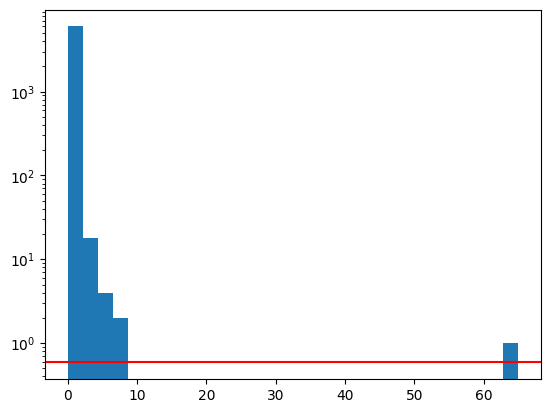

In [37]:
plt.hist(df[['Kilometers_Driven']]/10e+04, bins=30, log=True)
plt.axhline((df['Kilometers_Driven']/10e+04).mean(), color='red')
plt.show()

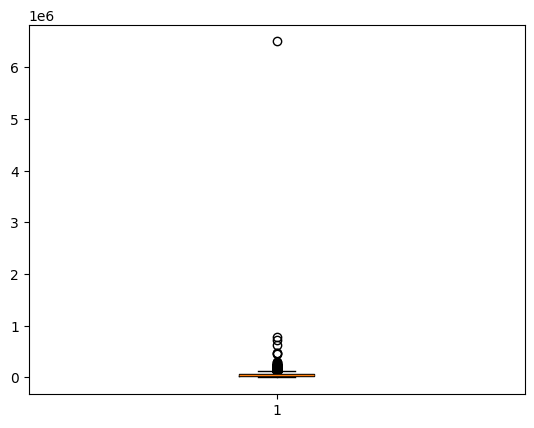

In [38]:
plt.boxplot(df['Kilometers_Driven'])
plt.show()

In [39]:
# A outlier
df.iloc[df['Kilometers_Driven'].argmax()]

Brand                                      BMW
Name                 BMW X5 xDrive 30d M Sport
Location                               Chennai
Year                                      2017
Kilometers_Driven                      6500000
Fuel_Type                               Diesel
Transmission                         Automatic
Owner_Type                               First
Mileage_kmpl                             15.97
Engine_CC                                 2993
Power_bhp                                258.0
Seats                                        5
Price_lakhs                               65.0
Name: 2328, dtype: object

<h4>Mileage<h4>

In [40]:
df['Mileage_kmpl'].describe()

count    6019.000000
mean       18.134966
std         4.581528
min         0.000000
25%        15.170000
50%        18.150000
75%        21.100000
max        33.540000
Name: Mileage_kmpl, dtype: float64

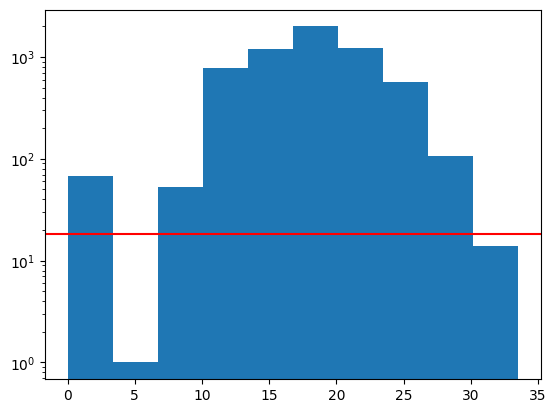

In [41]:
plt.hist(df['Mileage_kmpl'], log=True)
plt.axhline(df['Mileage_kmpl'].mean(), color='red')
plt.show()

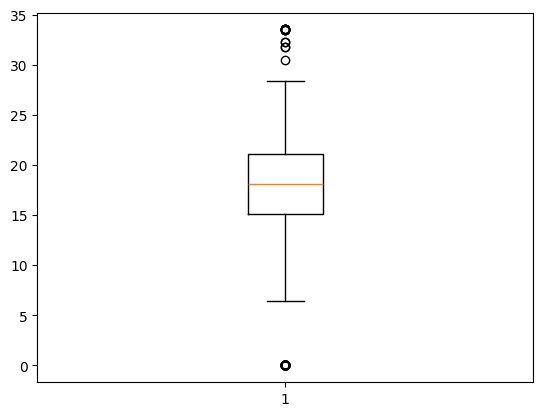

In [42]:
plt.boxplot(df['Mileage_kmpl'])
plt.show()

In [43]:
# A outlier
df.iloc[df['Mileage_kmpl'].argmin()]

Brand                                          Land
Name                 Land Rover Freelander 2 TD4 SE
Location                                       Pune
Year                                           2012
Kilometers_Driven                             85000
Fuel_Type                                    Diesel
Transmission                              Automatic
Owner_Type                                   Second
Mileage_kmpl                                    0.0
Engine_CC                                      2179
Power_bhp                                     115.0
Seats                                             5
Price_lakhs                                    17.5
Name: 14, dtype: object

In [44]:
df[df['Mileage_kmpl']<5]

,Brand,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price_lakhs
S.No.,,,,,,,,,,,,,
14,Land,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179,115.00000,5,17.50
67,Mercedes-Benz,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950,194.00000,5,35.67
79,Hyundai,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.0,1086,113.25305,5,1.30
194,Honda,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0,1493,113.25305,5,2.95
229,Ford,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,0.0,1498,99.00000,5,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5647,Toyota,Toyota Qualis Fleet A3,Mumbai,2001,227000,Diesel,Manual,Fourth & Above,0.0,2446,113.25305,8,2.20
5875,Mercedes-Benz,Mercedes-Benz C-Class Progressive C 220d,Ahmedabad,2019,4000,Diesel,Automatic,First,0.0,1950,194.00000,5,35.00
5943,Mahindra,Mahindra Jeep MM 540 DP,Chennai,2002,75000,Diesel,Manual,First,0.0,2112,113.25305,6,1.70


<h4>Power<h4>

In [45]:
df['Power_bhp'].describe()

count    6019.000000
mean      113.253050
std        53.231019
min        34.200000
25%        78.000000
50%        98.600000
75%       138.030000
max       560.000000
Name: Power_bhp, dtype: float64

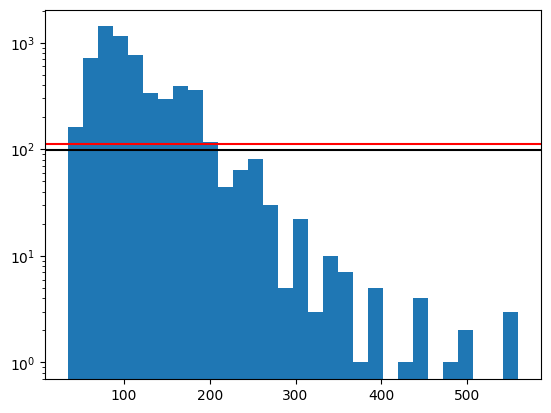

In [46]:
plt.hist(df['Power_bhp'], log=True, bins=30)
plt.axhline(df['Power_bhp'].mean(), color='red')
plt.axhline(df['Power_bhp'].median(), color='black')
plt.show()

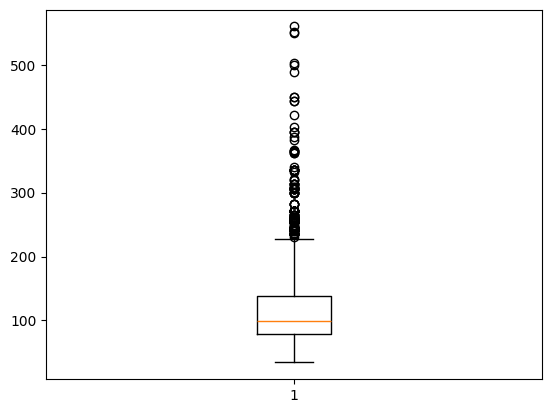

In [47]:
plt.boxplot(df['Power_bhp'])
plt.show()